In [5]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(
    "../data/processed/vessel_arrival_delay_feature_engineered.csv"
)

In [7]:
feature_columns = [

    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",

    "Distance_NM",
    "Scheduled_Transit_Days",
    "Departure_Delay_Hours",
    "Average_Speed_Knots",
    "Vessel_Age",
    "Cargo_Load_Percentage",
    "Port_Congestion_Index",
    "Weather_Severity",
    "Fuel_Price_USD",
    "Historical_Route_Delay",

    "Season",
    "Customs_Clearance_Risk",

    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category",

    "Delay_Risk_Score"
]

X = df[feature_columns]

y = df["Late_Arrival"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
numeric_features = [

    "Distance_NM",
    "Scheduled_Transit_Days",
    "Departure_Delay_Hours",
    "Average_Speed_Knots",
    "Vessel_Age",
    "Cargo_Load_Percentage",
    "Port_Congestion_Index",
    "Weather_Severity",
    "Fuel_Price_USD",
    "Historical_Route_Delay",
    "Delay_Risk_Score"

]

categorical_features = [

    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",

    "Season",
    "Customs_Clearance_Risk",

    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category"

]

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )

    ]
)

In [10]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)

}

In [11]:
results = []

for model_name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("classifier", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    probabilities = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc_auc = roc_auc_score(y_test, probabilities)

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })

In [12]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Gradient Boosting,0.948684,0.958318,0.985464,0.971702,0.974131
0,Logistic Regression,0.952016,0.967932,0.978755,0.973314,0.970830
2,Random Forest,0.940020,0.947124,0.988073,0.967165,0.962235
1,Decision Tree,0.929357,0.958102,0.963101,0.960595,0.803878


In [13]:
best_model_name = results_df.sort_values(

    by="ROC AUC",

    ascending=False

).iloc[0]["Model"]

print(best_model_name)

Gradient Boosting


In [15]:
best_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(random_state=42))

])

best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Carrier','Vessel_Type','Origin_Port',...,'Load_Category', 'Speed_Category','Delay_Risk_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

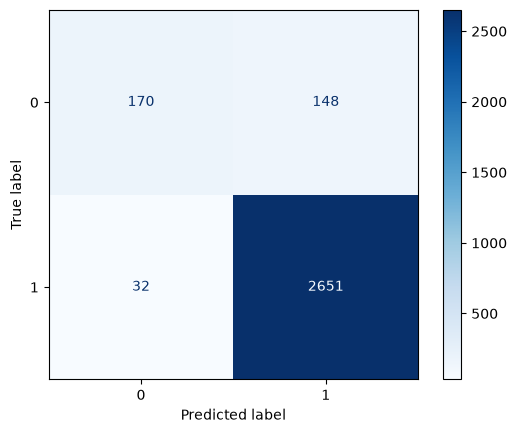

In [16]:
predictions = best_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(

    y_test,

    predictions,

    cmap="Blues"

)

plt.show()

In [17]:
print(classification_report(

    y_test,

    predictions
))

              precision    recall  f1-score   support

           0       0.84      0.53      0.65       318
           1       0.95      0.99      0.97      2683

    accuracy                           0.94      3001
   macro avg       0.89      0.76      0.81      3001
weighted avg       0.94      0.94      0.93      3001



In [18]:
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance = best_pipeline.named_steps[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": feature_importance

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False
)

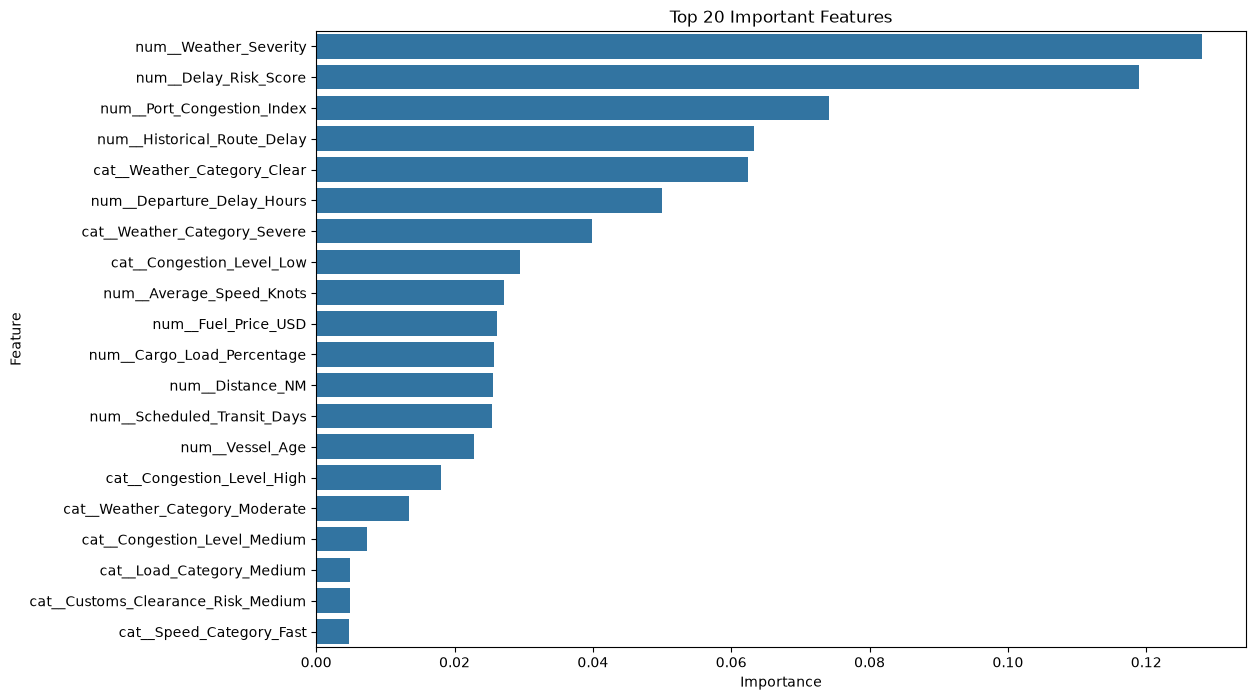

In [19]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [20]:
import joblib

joblib.dump(

    best_pipeline,

    "../models/best_model.pkl"

)

print("Model saved successfully!")

Model saved successfully!
